# Romance Novel Ambient-Sound Loudness Analysis

Tests whether **ambient sound loudness standard deviation** correlates with erotic scenes in annotated romance fiction TEI XML.

### Nudity assessment scale
| Value | Meaning |
|---|---|
| 0 | Absent — no erotic content |
| 1 | Weak — mild / suggestive |
| 2 | Strong — explicit erotic content |

### Schema assumptions
- One XML file per novel in `novels/`
- `<nudity assessment="N">` wraps `<scene n="N">`
- `<character_sound loudness="N.N">` inside `<scene>`
- `<ambient_sound loudness="N.N">` inside `<scene>` (optional)
- Sound elements **without** `@loudness` are skipped
- Violence annotations live in a separate file (stub at end)

### Outputs
- `output/scene_data.csv` — one row per scene, all features
- `output/results_summary_ambient.txt` — full statistical results
- `output/plots/` — violin plots, ROC curve, per-novel boxplot


## 0. Install dependencies
Run once if any packages are missing.

In [ ]:
#!pip install lxml scipy statsmodels scikit-learn matplotlib seaborn pandas numpy

## 1. Imports

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from lxml import etree

from scipy import stats
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## 2. Configuration

**Edit the paths and threshold here before running the rest of the notebook.**

In [1]:
# ── Paths ──────────────────────────────────────────────────────────────────

INPUT_DIR  = Path("/Users/.../nudity_annotated/scene_sound_nudity_annotated")          # folder containing the 10 TEI XML files
OUTPUT_DIR = Path("/Users/.../results_nudity-sound-correlation_analysis")          # all results written here
PLOTS_DIR  = OUTPUT_DIR / "/Users/.../results_nudity-sound-correlation_analysis/plots"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Nudity assessment scale ────────────────────────────────────────────────
#   0 = absent   (no erotic content)
#   1 = weak     (mild / suggestive)
#   2 = strong   (explicit erotic content)
#
# EROTIC_THRESHOLD controls which scenes count as 'erotic':
#   1  →  weak AND strong scenes are erotic  (recommended default)
#   2  →  only strong scenes are erotic      (stricter, smaller positive class)
EROTIC_THRESHOLD = 1

# TEI namespace — the parser retries without it automatically if needed
NS = {"tei": "http://www.tei-c.org/ns/1.0"}

print(f"Input  : {INPUT_DIR.resolve()}")
print(f"Output : {OUTPUT_DIR.resolve()}")
print(f"Erotic threshold : nudity assessment >= {EROTIC_THRESHOLD} "
      f"({'weak+strong' if EROTIC_THRESHOLD == 1 else 'strong only'})")

NameError: name 'Path' is not defined

## 3. Helper functions

In [ ]:
def tei_find(element, xpath, ns=NS):
    """XPath search that works with or without the TEI namespace prefix."""
    try:
        results = element.xpath(xpath, namespaces=ns)
        if not results:
            results = element.xpath(re.sub(r'tei:', '', xpath))
        return results
    except etree.XPathEvalError:
        return []


def extract_loudness_values(scene_el, sound_tag):
    """Return list of float loudness values for a given sound element tag.
    Elements without @loudness are silently skipped."""
    sounds = tei_find(scene_el, f".//tei:{sound_tag}[@loudness]")
    values = []
    for s in sounds:
        try:
            values.append(float(s.get("loudness")))
        except (TypeError, ValueError):
            pass
    return values


def scene_stats(loudness_values):
    """Compute descriptive statistics for a list of loudness values.
    Returns NaN for all stats when fewer than 2 values are present."""
    if len(loudness_values) < 2:
        return dict(n=len(loudness_values),
                    mean=np.nan, std=np.nan, median=np.nan,
                    iqr=np.nan, vrange=np.nan, min=np.nan, max=np.nan)
    arr = np.array(loudness_values)
    return dict(
        n      = len(arr),
        mean   = arr.mean(),
        std    = arr.std(ddof=1),
        median = np.median(arr),
        iqr    = float(np.percentile(arr, 75) - np.percentile(arr, 25)),
        vrange = float(arr.max() - arr.min()),
        min    = float(arr.min()),
        max    = float(arr.max()),
    )

print("Helper functions defined.")

Helper functions defined.


## 4. Parse all novels

In [ ]:
def parse_novel(xml_path):
    """Parse one TEI XML file; return a list of dicts, one per scene."""
    novel_id = xml_path.stem
    tree     = etree.parse(str(xml_path))
    root     = tree.getroot()
    records  = []

    nudity_elements = (tei_find(root, ".//tei:nudity") or
                       tei_find(root, ".//nudity"))

    for nudity_el in nudity_elements:
        try:
            nudity_score = int(nudity_el.get("assessment", 0))
        except (TypeError, ValueError):
            nudity_score = 0

        # Map 0/1/2 to human-readable label
        nudity_label = {0: "absent", 1: "weak", 2: "strong"}.get(nudity_score, "unknown")
        is_erotic    = int(nudity_score >= EROTIC_THRESHOLD)

        scenes = (tei_find(nudity_el, ".//tei:scene") or
                  tei_find(nudity_el, ".//scene"))

        for scene_el in scenes:
            scene_n    = scene_el.get("n", "?")
            char_vals  = extract_loudness_values(scene_el, "character_sound")
            char_st    = scene_stats(char_vals)
            amb_vals   = extract_loudness_values(scene_el, "ambient_sound")
            amb_st     = scene_stats(amb_vals)
            word_count = len(etree.tostring(scene_el,
                             method="text", encoding="unicode").split())

            records.append(dict(
                novel_id      = novel_id,
                scene_n       = scene_n,
                nudity_score  = nudity_score,
                nudity_label  = nudity_label,
                is_erotic     = is_erotic,
                word_count    = word_count,
                # character sound
                char_n        = char_st["n"],
                char_mean     = char_st["mean"],
                char_std      = char_st["std"],
                char_median   = char_st["median"],
                char_iqr      = char_st["iqr"],
                char_range    = char_st["vrange"],
                char_min      = char_st["min"],
                char_max      = char_st["max"],
                # ambient sound
                amb_n         = amb_st["n"],
                amb_mean      = amb_st["mean"],
                amb_std       = amb_st["std"],
                amb_median    = amb_st["median"],
                amb_iqr       = amb_st["iqr"],
                amb_range     = amb_st["vrange"],
            ))
    return records


# ── Run extraction ────────────────────────────────────────────────────────
xml_files = sorted(INPUT_DIR.glob("*.xml"))

if not xml_files:
    raise FileNotFoundError(
        f"No XML files found in '{INPUT_DIR}'. "
        "Place your 10 TEI files there and re-run this cell.")

all_records = []
for f in xml_files:
    print(f"Parsing {f.name} …")
    all_records.extend(parse_novel(f))

df = pd.DataFrame(all_records)
df.to_csv(OUTPUT_DIR / "scene_data.csv", index=False)

print(f"\nTotal scenes extracted : {len(df)}")
print(df["nudity_label"].value_counts().to_string())
df.head()

Parsing Cowboy_Be_Mine_TEXAS.xml …
Parsing Deceptions-CALIFORNIA.xml …
Parsing Finders_Keepers_VERMONT.xml …
Parsing Found_His_Perfect_Wife_ALASKA.xml …
Parsing Love_by_Proxy_ILLINOIS.xml …
Parsing Midnight_Wishes_WYOMING.xml …
Parsing Pros_and_Cons_MASSACHUSETTS.xml …
Parsing Tangled_Lies_HAWAII.xml …
Parsing Too_Near_the_Fire_OHIO_corrected_speaker.xml …
Parsing Warriors_Embrace_MISSISSIPPI.xml …

Total scenes extracted : 815
nudity_label
weak      390
absent    331
strong     94


,novel_id,scene_n,nudity_score,nudity_label,is_erotic,word_count,char_n,char_mean,char_std,char_median,char_iqr,char_range,char_min,char_max,amb_n,amb_mean,amb_std,amb_median,amb_iqr,amb_range
0,Cowboy_Be_Mine_TEXAS,1,1,weak,1,702,4,2.750000,0.500000,3.0,0.25,1.0,2.0,3.0,0,NaN,NaN,NaN,NaN,NaN
1,Cowboy_Be_Mine_TEXAS,2,1,weak,1,480,5,3.000000,0.000000,3.0,0.00,0.0,3.0,3.0,0,NaN,NaN,NaN,NaN,NaN
2,Cowboy_Be_Mine_TEXAS,3,0,absent,0,1325,11,3.045455,0.350325,3.0,0.00,1.5,2.5,4.0,2,2.0,1.414214,2.0,1.0,2.0
3,Cowboy_Be_Mine_TEXAS,4,0,absent,0,635,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4.0,0.000000,4.0,0.0,0.0
4,Cowboy_Be_Mine_TEXAS,5,1,weak,1,464,3,3.666667,0.577350,4.0,0.50,1.0,3.0,4.0,1,NaN,NaN,NaN,NaN,NaN


## 5. Prepare analysis subset

Restrict to scenes with **≥ 2 ambient sound events** (standard deviation is undefined for fewer than 2 values).


In [ ]:
df_valid = df[df["amb_n"] >= 2].copy()

# Ordered categorical for nudity label (used in plots)
df_valid["nudity_label"] = pd.Categorical(
    df_valid["nudity_label"],
    categories=["absent", "weak", "strong"],
    ordered=True
)

erotic_mask     = df_valid["is_erotic"] == 1
non_erotic_mask = df_valid["is_erotic"] == 0

print(f"Scenes with >= 2 ambient sound events : {len(df_valid)}")
print(f"  Absent  (score 0) : {(df_valid['nudity_score']==0).sum()}")
print(f"  Weak    (score 1) : {(df_valid['nudity_score']==1).sum()}")
print(f"  Strong  (score 2) : {(df_valid['nudity_score']==2).sum()}")
print(f"  ── Erotic total (>= {EROTIC_THRESHOLD}) : {erotic_mask.sum()}")
print(f"  ── Non-erotic        : {non_erotic_mask.sum()}")


Scenes with >= 2 ambient sound events : 146
  Absent  (score 0) : 52
  Weak    (score 1) : 72
  Strong  (score 2) : 22
  ── Erotic total (>= 1) : 94
  ── Non-erotic        : 52


## 6. Descriptive statistics

In [ ]:
# ── By binary erotic label ────────────────────────────────────────────────
print("Ambient sound std  —  by scene type")
print("=" * 45)
for label, mask in [("Non-erotic (absent)", non_erotic_mask),
                    ("Erotic (weak+strong)", erotic_mask)]:
    s = df_valid.loc[mask, "amb_std"].dropna()
    print(f"\n{label}  (n={len(s)})")
    print(f"  Mean   : {s.mean():.3f}")
    print(f"  Median : {s.median():.3f}")
    print(f"  SD     : {s.std():.3f}")
    print(f"  Range  : {s.min():.3f} – {s.max():.3f}")

print()
print("Ambient sound std  —  by nudity score (0 / 1 / 2)")
print("=" * 45)
print(df_valid.groupby("nudity_score")["amb_std"]
      .agg(["count", "mean", "median", "std"])
      .rename(columns={"count":"n", "mean":"mean_std",
                       "median":"median_std", "std":"sd_of_std"})
      .round(3)
      .to_string())


Ambient sound std  —  by scene type

Non-erotic (absent)  (n=52)
  Mean   : 0.699
  Median : 0.636
  SD     : 0.639
  Range  : 0.000 – 2.475

Erotic (weak+strong)  (n=94)
  Mean   : 0.744
  Median : 0.707
  SD     : 0.590
  Range  : 0.000 – 2.828

Ambient sound std  —  by nudity score (0 / 1 / 2)
               n  mean_std  median_std  sd_of_std
nudity_score                                     
0             52     0.699       0.636      0.639
1             72     0.753       0.691      0.629
2             22     0.713       0.707      0.450


## 7. Statistical tests

In [2]:
erotic_std     = df_valid.loc[erotic_mask,     "amb_std"].dropna()
non_erotic_std = df_valid.loc[non_erotic_mask, "amb_std"].dropna()
results_lines  = []

def log(msg=""):
    print(msg)
    results_lines.append(msg)

# ── 1. Mann-Whitney U (primary test) ──────────────────────────────────────
log("1. MANN-WHITNEY U TEST")
log("   H1: erotic scenes have higher amb_std than non-erotic")
log("-" * 55)
if len(erotic_std) > 0 and len(non_erotic_std) > 0:
    u_stat, p_val = mannwhitneyu(erotic_std, non_erotic_std, alternative="greater")
    n1, n2 = len(erotic_std), len(non_erotic_std)
    r_rb   = 1 - (2 * u_stat) / (n1 * n2)   # rank-biserial effect size
    log(f"   U = {u_stat:.1f}")
    log(f"   p = {p_val:.4f}  (one-tailed)")
    log(f"   Rank-biserial r = {r_rb:.3f}  (effect size)")
    log(f"   → {'Significant' if p_val < 0.05 else 'Not significant'} at α = 0.05")
else:
    log("   Insufficient data.")

log()

# ── 2. Point-biserial correlation ─────────────────────────────────────────
log("2. POINT-BISERIAL CORRELATION  (amb_std ~ is_erotic)")
log("-" * 55)
pb_data = df_valid[["amb_std", "is_erotic"]].dropna()
if len(pb_data) > 3:
    r_pb, p_pb = pointbiserialr(pb_data["is_erotic"], pb_data["amb_std"])
    log(f"   r_pb = {r_pb:.3f},  p = {p_pb:.4f}")
else:
    log("   Insufficient data.")

log()

# ── 3. Spearman rho (ordinal nudity score 0/1/2) ──────────────────────────
log("3. SPEARMAN CORRELATION  (amb_std ~ nudity_score ordinal 0/1/2)")
log("-" * 55)
sp_data = df_valid[["amb_std", "nudity_score"]].dropna()
if len(sp_data) > 3:
    rho, p_rho = stats.spearmanr(sp_data["amb_std"], sp_data["nudity_score"])
    log(f"   Spearman ρ = {rho:.3f},  p = {p_rho:.4f}")
else:
    log("   Insufficient data.")

log()

# ── 4. ROC / AUC ──────────────────────────────────────────────────────────
log("4. ROC / AUC  (amb_std as predictor of erotic label)")
log("-" * 55)
roc_data = df_valid[["amb_std", "is_erotic"]].dropna()
auc = None
if roc_data["is_erotic"].nunique() == 2 and len(roc_data) >= 5:
    auc = roc_auc_score(roc_data["is_erotic"], roc_data["amb_std"])
    log(f"   AUC = {auc:.3f}  (0.5 = chance, 1.0 = perfect)")
    log(f"   → amb_std is {'better than' if auc > 0.5 else 'no better than'} "
        f"chance at discriminating erotic scenes")
else:
    log("   Insufficient class variation for ROC.")

# ── Save results ──────────────────────────────────────────────────────────
results_path = OUTPUT_DIR / "results_summary_ambient.txt"
with open(results_path, "w", encoding="utf-8") as f:
    f.write("\n".join(results_lines))
print(f"\nResults saved to {results_path}")


NameError: name 'df_valid' is not defined

## 8. Plots

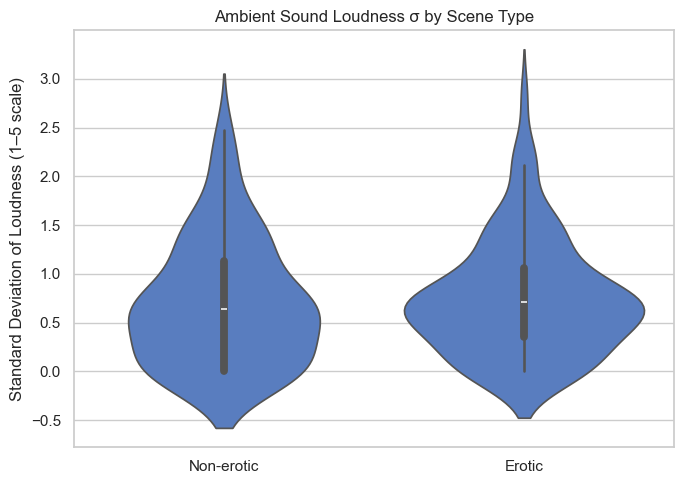

Saved violin_amb_std.png


In [ ]:
sns.set_theme(style="whitegrid", palette="muted")

# ── 8a. Violin: amb_std by binary scene type ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
plot_df = df_valid.dropna(subset=["amb_std"]).copy()
plot_df["Scene type"] = plot_df["is_erotic"].map({0: "Non-erotic", 1: "Erotic"})
sns.violinplot(data=plot_df, x="Scene type", y="amb_std",
               order=["Non-erotic", "Erotic"], inner="box", ax=ax)
ax.set_title("Ambient Sound Loudness σ by Scene Type")
ax.set_ylabel("Standard Deviation of Loudness (1–5 scale)")
ax.set_xlabel("")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "violin_amb_std.png", dpi=150)
plt.show()
print("Saved violin_amb_std.png")


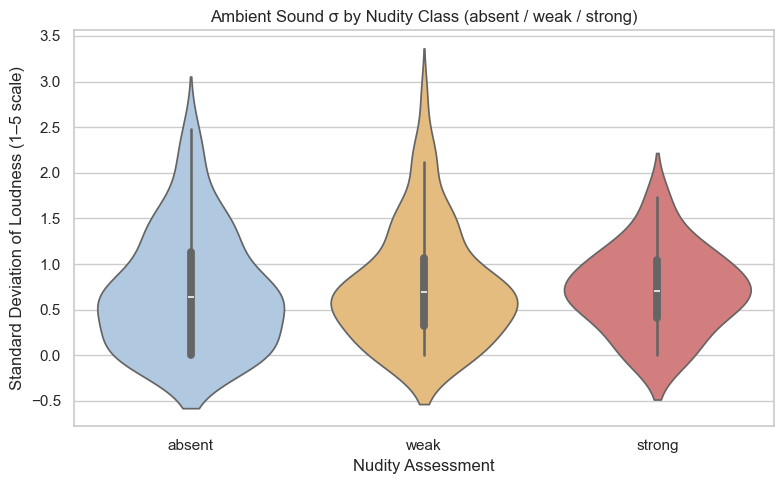

Saved violin_amb_std_by_nudity_class.png


In [ ]:
# ── 8b. Violin: amb_std across all three nudity classes (0 / 1 / 2) ──────
fig, ax = plt.subplots(figsize=(8, 5))
label_order = ["absent", "weak", "strong"]
palette     = {"absent": "#a8c8e8", "weak": "#f5c06e", "strong": "#e07070"}
sns.violinplot(data=plot_df, x="nudity_label", y="amb_std",
               order=label_order, palette=palette, inner="box", ax=ax)
ax.set_title("Ambient Sound σ by Nudity Class (absent / weak / strong)")
ax.set_ylabel("Standard Deviation of Loudness (1–5 scale)")
ax.set_xlabel("Nudity Assessment")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "violin_amb_std_by_nudity_class.png", dpi=150)
plt.show()
print("Saved violin_amb_std_by_nudity_class.png")


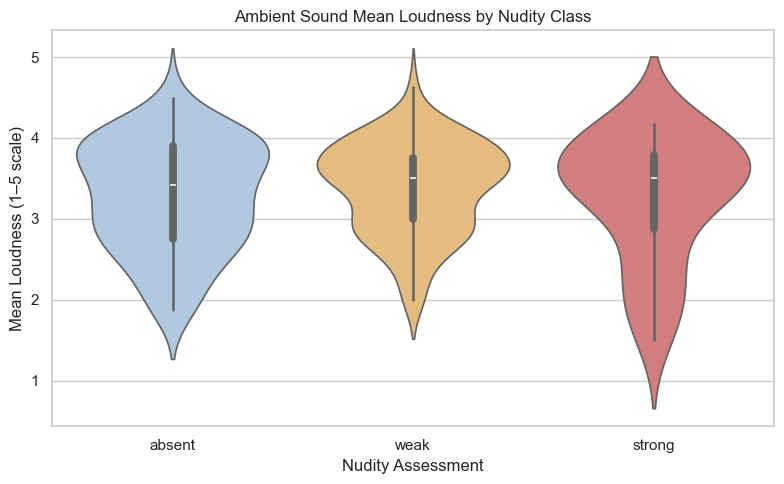

Saved violin_amb_mean_by_nudity_class.png


In [ ]:
# ── 8c. Violin: amb_mean across nudity classes ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=plot_df, x="nudity_label", y="amb_mean",
               order=label_order, palette=palette, inner="box", ax=ax)
ax.set_title("Ambient Sound Mean Loudness by Nudity Class")
ax.set_ylabel("Mean Loudness (1–5 scale)")
ax.set_xlabel("Nudity Assessment")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "violin_amb_mean_by_nudity_class.png", dpi=150)
plt.show()
print("Saved violin_amb_mean_by_nudity_class.png")


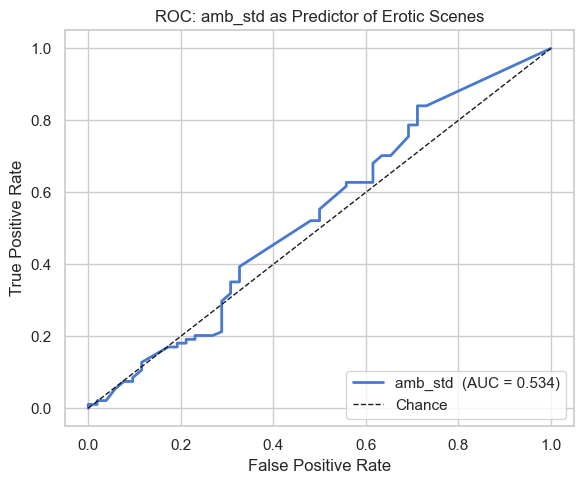

Saved roc_curve_ambient.png


In [ ]:
# ── 8d. ROC curve ─────────────────────────────────────────────────────────
if auc is not None:
    fpr, tpr, _ = roc_curve(roc_data["is_erotic"], roc_data["amb_std"])
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, lw=2, label=f"amb_std  (AUC = {auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC: amb_std as Predictor of Erotic Scenes")
    ax.legend(loc="lower right")
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / "roc_curve_ambient.png", dpi=150)
    plt.show()
    print("Saved roc_curve_ambient.png")
else:
    print("ROC skipped — insufficient class variation.")


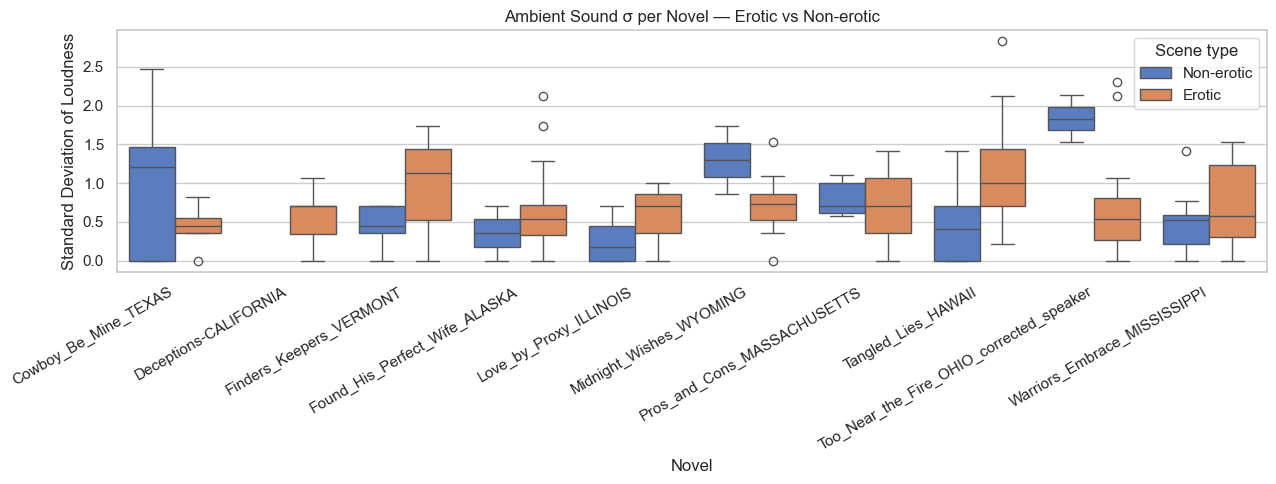

Saved boxplot_amb_per_novel.png


In [ ]:
# ── 8e. Per-novel boxplot of amb_std ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
novel_order = sorted(plot_df["novel_id"].unique())
sns.boxplot(data=plot_df, x="novel_id", y="amb_std",
            hue="Scene type", order=novel_order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_title("Ambient Sound σ per Novel — Erotic vs Non-erotic")
ax.set_xlabel("Novel")
ax.set_ylabel("Standard Deviation of Loudness")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "boxplot_amb_per_novel.png", dpi=150)
plt.show()
print("Saved boxplot_amb_per_novel.png")


## 9. Sensitivity check: strong-only erotic scenes

Re-runs the Mann-Whitney test restricting the erotic class to **score 2 (strong)** only, leaving score 1 (weak) out of both groups. This isolates whether the effect is driven by explicit scenes specifically.


In [ ]:
strong_std  = df_valid.loc[df_valid["nudity_score"] == 2, "amb_std"].dropna()
absent_std  = df_valid.loc[df_valid["nudity_score"] == 0, "amb_std"].dropna()

print("Sensitivity check: strong (score 2) vs absent (score 0)")
print("-" * 50)
if len(strong_std) > 0 and len(absent_std) > 0:
    u2, p2  = mannwhitneyu(strong_std, absent_std, alternative="greater")
    r2      = 1 - (2 * u2) / (len(strong_std) * len(absent_std))
    print(f"Strong  n={len(strong_std)},  mean std = {strong_std.mean():.3f}")
    print(f"Absent  n={len(absent_std)},  mean std = {absent_std.mean():.3f}")
    print(f"U = {u2:.1f},  p = {p2:.4f},  rank-biserial r = {r2:.3f}")
    print(f"→ {'Significant' if p2 < 0.05 else 'Not significant'} at α = 0.05")
else:
    print("Insufficient data for one or both groups.")


Sensitivity check: strong (score 2) vs absent (score 0)
--------------------------------------------------
Strong  n=22,  mean std = 0.713
Absent  n=52,  mean std = 0.699
U = 621.0,  p = 0.2814,  rank-biserial r = -0.086
→ Not significant at α = 0.05


## 10. Violence annotation stub

When you are ready to integrate the separate violence annotation files, implement the function below and merge on `(novel_id, scene_n)`. This enables the key confound check: does high amb_std predict *erotic* scenes specifically, or violent scenes equally?


In [ ]:
# STUB — fill in once you know the violence annotation file format
#
# def load_violence_annotations(violence_dir: Path) -> pd.DataFrame:
#     """
#     Parse standoff violence annotation files.
#     Returns a DataFrame with columns: novel_id, scene_n, violence_score, violence_label
#     violence_label mirrors nudity: 0=absent, 1=weak, 2=strong
#     """
#     records = []
#     for f in sorted(violence_dir.glob("*.xml")):
#         ...  # parse and append to records
#     return pd.DataFrame(records)
#
# violence_df = load_violence_annotations(Path("violence_annotations"))
# df_merged   = df_valid.merge(violence_df, on=["novel_id", "scene_n"], how="left")
#
# # Four-way scene category
# def categorise(row):
#     e = row["nudity_score"] >= 1
#     v = row["violence_score"] >= 1
#     if e and v:  return "erotic+violent"
#     if e:        return "erotic"
#     if v:        return "violent"
#     return "neutral"
#
# df_merged["scene_category"] = df_merged.apply(categorise, axis=1)
# print(df_merged["scene_category"].value_counts())

print("Violence stub ready — implement load_violence_annotations() when needed.")

Violence stub ready — implement load_violence_annotations() when needed.
